[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jeremydwong/bonelab_inverse_dynamics/blob/main/notebooks/quickstart_report.ipynb)

# Inverse Dynamics in Ten Steps

The notebook form of `examples/quickstart.py`: one high-level call per step,
from raw mocap and force data to net joint torques, the residual wrench, and
the energy audit.

## How to run this notebook

```bash
uv run jupyter lab notebooks/quickstart_report.ipynb        # interactive
uv run jupyter nbconvert --to script notebooks/quickstart_report.ipynb   # -> .py
```

On Colab, run the bootstrap cell below and set `DATA_URL` first.

In [1]:
# Colab bootstrap — a no-op when running locally in the uv environment.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "boneid @ git+https://github.com/jeremydwong/bonelab_inverse_dynamics"],
                   check=True)
os.makedirs("../reports", exist_ok=True)

# Data: on Colab, paste a DIRECT download link to p1_5StridesData.mat
# (e.g. a Dropbox share link with ?dl=1). Locally the Dropbox path is used.
# Full P1 data (84 MB) lives on the repo's GitHub release; the 2.5 MB
# single-trial sample is committed at data/p1_trial13_sample.mat.
DATA_URL = "https://github.com/jeremydwong/bonelab_inverse_dynamics/releases/download/data-p1-v1/p1_5StridesData.mat"  # needs the repo to be public (or auth) to resolve
if IN_COLAB:
    if not os.path.exists("p1_5StridesData.mat"):
        import urllib.request
        urllib.request.urlretrieve(DATA_URL, "p1_5StridesData.mat")
        print("downloaded p1_5StridesData.mat")

## Study config — the only thing you edit

In [2]:
import numpy as np

MAT_PATH = "/Users/jeremy/Dropbox/Public/inverse-dynamics-test-data/p1_5StridesData.mat"
if not os.path.exists(MAT_PATH):
    for alt in ("p1_5StridesData.mat",              # the Colab download
                "../data/p1_trial13_sample.mat"):   # committed sample
        if os.path.exists(alt):
            MAT_PATH = alt
            break
TRIAL_INDEX = 13
CONTACT_THRESHOLD_N = 20.0     # vertical force marking ground contact
KINEMATIC_LOWPASS_HZ = 12.0    # segment-pose filter before differentiation
TREADMILL_ORIGIN = np.zeros(3)  # fixed lab point the ground wrench is about

## Step 1 — mocap data: markers, landmarks, rates

In [3]:
from boneid.io_v3d import load_v3d_trials

trials = load_v3d_trials(MAT_PATH)
trial = trials[TRIAL_INDEX] if len(trials) > TRIAL_INDEX else trials[0]
print(f"trial {trial.index}: {len(trial.t)} frames at {trial.rate:.0f} Hz, "
      f"{len(trial.markers)} markers, analog {trial.analog_rate:.0f} Hz")

trial 13: 637 frames at 120 Hz, 35 markers, analog 1200 Hz


## Step 2 — force data (rides on the trial)\n\nPer-belt force, COP, and free moment at the analog rate.

In [4]:
print("force", trial.force.shape, "| cop", trial.cop.shape,
      "| free moment", trial.free_moment.shape, "| plates", len(trial.plates))

force (6363, 2, 3) | cop (6363, 2, 3) | free moment (6363, 2, 3) | plates 2


## Step 3 — skeleton: body mass from the force record + de Leva regressions

In [5]:
from boneid.io_v3d import estimate_body_mass

body_mass = estimate_body_mass(trial, threshold_n=CONTACT_THRESHOLD_N)
print(f"body mass from mean vertical GRF: {body_mass:.1f} kg")

body mass from mean vertical GRF: 85.0 kg


## Step 4 — treadmill definition & analysis parameters\n\nTorques are taken about a fixed lab point (the treadmill origin) — no center-of-pressure division anywhere. Force anti-alias filtering already happened in the loader, so `force_lowpass_hz` stays 0.

In [6]:
from boneid.core import AnalysisParams

params = AnalysisParams(contact_threshold_n=CONTACT_THRESHOLD_N,
                        lowpass_hz=KINEMATIC_LOWPASS_HZ,
                        force_lowpass_hz=0.0)
params

AnalysisParams(gravity=array([ 0.  ,  0.  , -9.81]), contact_threshold_n=20.0, lowpass_hz=12.0, force_lowpass_hz=0.0, filter_order=4, treadmill_speed=0.0, flag_crossover=False)

## Step 5 — segment kinematics: one call per side, plus the upper body

In [7]:
from boneid.io_v3d import build_chain, build_upper_body

skel_r, kin_r, ground_r = build_chain(trial, side="r", point=TREADMILL_ORIGIN,
                                      threshold_n=CONTACT_THRESHOLD_N)
skel_l, kin_l, ground_l = build_chain(trial, side="l", point=TREADMILL_ORIGIN,
                                      threshold_n=CONTACT_THRESHOLD_N)
skel_u, kin_u = build_upper_body(trial)
print("legs:", skel_r.segment_names, "| upper body:", skel_u.segment_names)
print(f"modeled mass: {skel_r.mass.sum() + skel_l.mass[:3].sum() + skel_u.mass.sum():.1f} "
      f"of {body_mass:.1f} kg")

legs: ['foot', 'shank', 'thigh', 'pelvis'] | upper body: ['r_forearm_hand', 'r_upper_arm', 'l_forearm_hand', 'l_upper_arm', 'torso']
modeled mass: 85.0 of 85.0 kg


## Step 6 — contact events and crossover flags

In [8]:
from boneid.core import detect_contact
from boneid.io_v3d import crossover_flags

contact = {s: detect_contact(g.force[:, 2], CONTACT_THRESHOLD_N)
           for s, g in (("r", ground_r), ("l", ground_l))}
crossover = {s: crossover_flags(trial, s, CONTACT_THRESHOLD_N) for s in "rl"}
for s in "rl":
    print(f"{s}: {len(contact[s][1])} contacts, "
          f"{int(crossover[s].sum())} crossover frames (double support)")

r: 6 contacts, 133 crossover frames (double support)
l: 6 contacts, 133 crossover frames (double support)


## Step 7 — inverse dynamics: whole body\n\nBoth legs bottom-up into the shared pelvis; L5S1 is a real joint; the arms hang from the shoulders; the residual lands at the torso.

In [9]:
from boneid.core import inverse_dynamics_whole_body

wb = inverse_dynamics_whole_body(skel_r, kin_r, ground_r,
                                 skel_l, kin_l, ground_l,
                                 skel_u, kin_u, params)

## Step 8 — the outputs: joint torques and the residual wrench

In [10]:
edge = slice(10, -10)
for s, res in (("R", wb.right), ("L", wb.left)):
    peaks = np.abs(res.joint_torque[edge]).max(axis=(0, 2))
    print(f"{s} peak |torque|: " + ", ".join(
        f"{n} {p:.0f} N m" for n, p in zip(("ankle", "knee", "hip"), peaks)))
print(f"residual at torso: mean Fz {wb.residual_force[edge, 2].mean():+.1f} N "
      f"(body weight {body_mass * 9.81:.0f} N)")
print(f"L5S1 mean Fz {wb.l5s1_force[edge, 2].mean():+.1f} N")

R peak |torque|: ankle 169 N m, knee 127 N m, hip 123 N m
L peak |torque|: ankle 156 N m, knee 145 N m, hip 137 N m
residual at torso: mean Fz -1.1 N (body weight 833 N)
L5S1 mean Fz -405.8 N


## Step 9 — the energy audit (always)

In [11]:
from boneid.core import energy_audit_whole_body

audit = energy_audit_whole_body(skel_r, kin_r, ground_r,
                                skel_l, kin_l, ground_l,
                                skel_u, kin_u, wb, params)
imb = np.abs(audit.imbalance[edge]).max()
pk = np.abs(audit.de_dt).max()
print(f"peak energy imbalance {imb:.1f} W of {pk:.0f} W peak dE/dt "
      f"({100 * imb / pk:.2f}%)")

peak energy imbalance 6.7 W of 781 W peak dE/dt (0.85%)


## Step 10 — the report

In [12]:
from pathlib import Path
from IPython.display import HTML, display
from boneid.report import p1_viewer_html, quickstart_report_html

viewer_html = p1_viewer_html(trial,
                             (skel_r, kin_r, ground_r, skel_l, kin_l, ground_l),
                             skel_u, kin_u, params)
html = quickstart_report_html(trial=trial, body_mass=body_mass, params=params,
                              chains={"r": (skel_r, kin_r, ground_r),
                                      "l": (skel_l, kin_l, ground_l)},
                              upper=(skel_u, kin_u),
                              contact=contact, crossover=crossover,
                              whole=wb, audit=audit,
                              viewer_html=viewer_html)
out = Path("../reports/quickstart_report.html")
out.write_text(html)
print(f"wrote {out.resolve()} ({out.stat().st_size / 1e6:.2f} MB)")

wrote /Users/jeremy/Git/brent/bonelab_inverse_dynamics/reports/quickstart_report.html (0.57 MB)


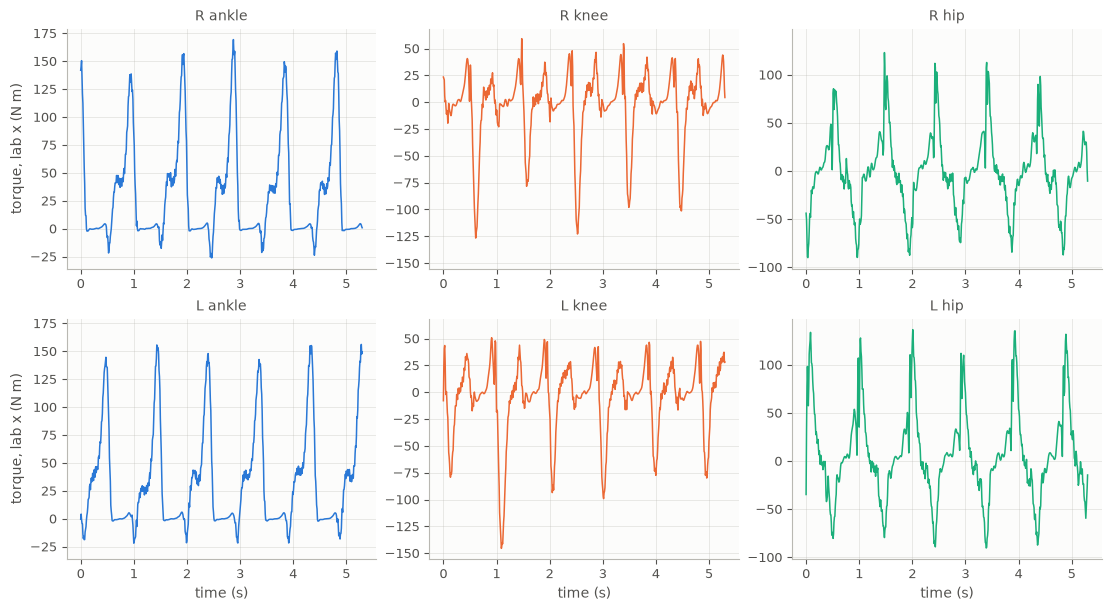

In [13]:
%matplotlib inline
# a quick inline look: both legs' sagittal torques, equal axes per joint
import matplotlib.pyplot as plt
from boneid.report import JOINT_COLORS, NEUTRAL, style_axes

fig, axes = plt.subplots(2, 3, figsize=(11, 6), constrained_layout=True)
t = kin_r.t
for row, (s, res) in enumerate((("R", wb.right), ("L", wb.left))):
    for j, name in enumerate(("ankle", "knee", "hip")):
        ax = axes[row, j]
        ax.plot(t, res.joint_torque[:, j, 0], color=JOINT_COLORS[j], lw=1.1)
        ax.set_title(f"{s} {name}", color=NEUTRAL, fontsize=10)
        style_axes(ax, "time (s)" if row else "", "torque, lab x (N m)" if j == 0 else "")
for j in range(3):
    lims = axes[0, j].get_ylim() + axes[1, j].get_ylim()
    for row in range(2):
        axes[row, j].set_ylim(min(lims), max(lims))
display(fig)  # report pins the Agg backend; display() renders it inline
plt.close(fig)